In [13]:
print ("Task 1: Dataset Understanding")

# Step 1: Import libraries
import pandas as pd

# Step 2: Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignment 5 part 3/customer_support_text_classification.csv")

# Step 3: Number of records
num_records = len(df)

# Step 4: Target labels/classes
labels = df['sentiment_label'].unique()

# Step 5: Sample text records
sample_records = df[['customer_message','sentiment_label']].sample(5, random_state=42)

# Step 6: Average text length (using word_count column)
avg_length = df['word_count'].mean()

# Step 7: Class distribution
class_dist = df['sentiment_label'].value_counts()

# Print results
print("\nDataset Understanding Results:\n")
print(f"Number of records: {num_records}\n")
print(f"Target labels/classes: {labels}")
print("\nSample text records:\n", sample_records)
print(f"\nAverage text length: {avg_length:.2f} words")
print("\nClass distribution:\n", class_dist)

Task 1: Dataset Understanding

Dataset Understanding Results:

Number of records: 1500

Target labels/classes: ['neutral' 'positive' 'negative']

Sample text records:
                                        customer_message sentiment_label
1116  I am checking if there is any scheduled mainte...         neutral
1368  The app experience is smooth and reliable. I a...        positive
422   Can you confirm whether my ticket has been ass...         neutral
413   I have raised multiple tickets but nobody has ...        negative
451   Billing is incorrect and I was charged twice t...        negative

Average text length: 12.72 words

Class distribution:
 sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [14]:
print ("Task 2: Text Preprocessing\n")
# Step 1: Import libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download stopwords (only first time)
nltk.download('stopwords')

# Step 2: Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignment 5 part 3/customer_support_text_classification.csv")

# Step 3: Lowercasing
df['clean_text'] = df['customer_message'].str.lower()

# Step 4: Remove symbols / special characters
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

# Step 5: Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Step 6: Remove stopwords (optional)
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])
df['clean_text'] = df['clean_text'].apply(remove_stopwords)

# Step 7: Padding / truncating sequences
max_len = 20  # we choose 20 words per sentence
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Show results
print("Cleaned sample text:\n", df['clean_text'].head())
print("\nFirst padded sequence:\n", padded_sequences[0])


Task 2: Text Preprocessing

Cleaned sample text:
 0    need information payment process ticket number...
1                     need information payment process
2    refund process fast convenient appreciate quic...
3    refund still pending experience frustrating ti...
4                   please tell update account details
Name: clean_text, dtype: object

First padded sequence:
 [  4  29 136  39   1  90  33   3   6   7   2  10  12   8  13   8  14   0
   0   0]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
print ("Task 3: Text Vectorization\n")

# Step 1: Import libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 2: Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignment 5 part 3/customer_support_text_classification.csv")

# Step 3: Bag of Words
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(df['customer_message'])
print("Bag of Words shape:", bow_matrix.shape)

# Step 4: TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['customer_message'])
print("TF-IDF shape:", tfidf_matrix.shape)

# Step 5: Tokenizer Sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['customer_message'])
sequences = tokenizer.texts_to_sequences(df['customer_message'])
padded_sequences = pad_sequences(sequences, maxlen=20, padding='post')
print("Tokenizer padded shape:", padded_sequences.shape)


Task 3: Text Vectorization

Bag of Words shape: (1500, 667)
TF-IDF shape: (1500, 667)
Tokenizer padded shape: (1500, 20)


Task 4: Baseline Model

Confusion Matrix:
 [[ 99   0   0]
 [  0 105   0]
 [  0   0  96]]
 Classification Report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



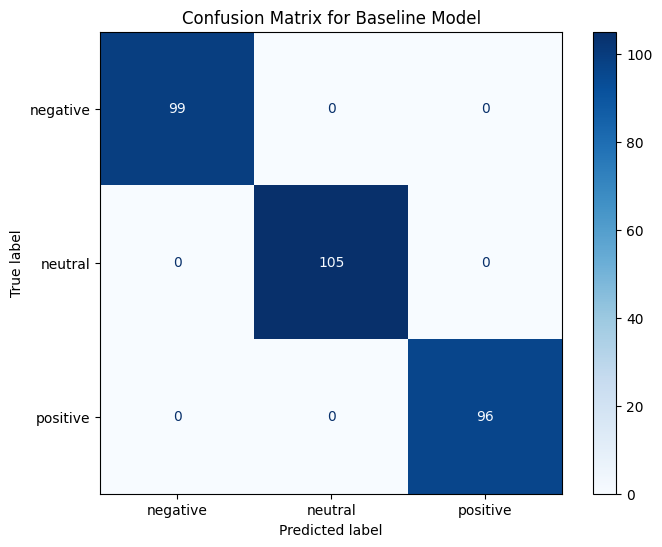

In [22]:
print ("Task 4: Baseline Model\n")
# Step 1: Import libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignment 5 part 3/customer_support_text_classification.csv")

# Step 3: TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df['customer_message'])
y = df['sentiment_label']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Train Logistic Regression baseline model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 6: Predictions
y_pred = model.predict(X_test)

# Step 7: Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(" Classification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Baseline Model')
plt.show()

Task 5: Sequence Model or Conceptual Architecture

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5667 - loss: 0.8628 - val_accuracy: 0.9700 - val_loss: 0.2178
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9983 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 8.9782e-04
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 7.9007e-04 - val_accuracy: 1.0000 - val_loss: 6.9538e-04
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 6.2232e-04 - val_accuracy: 1.0000 - val_loss: 5.5819e-04
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s

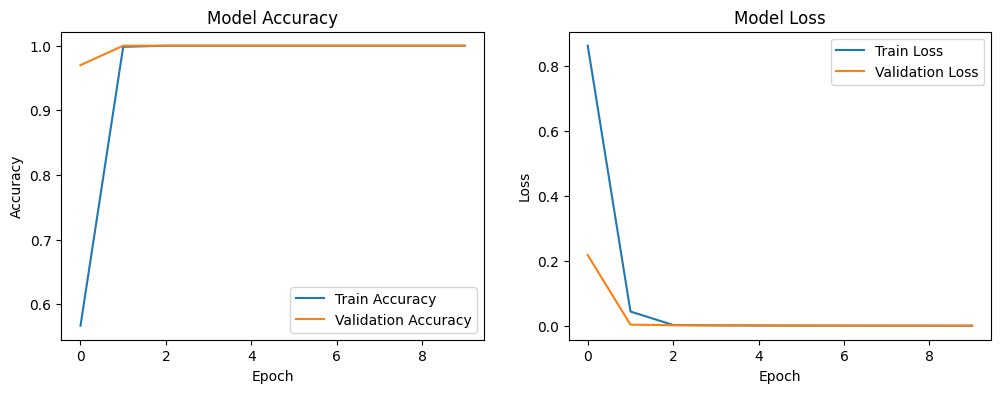

In [25]:
print ("Task 5: Sequence Model or Conceptual Architecture\n")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import pandas as pd # Ensure df is available

# Parameters
vocab_size = 5000   # number of unique words
embedding_dim = 64  # size of word meaning vectors
max_len = 20        # max words per message

# --- Data Preparation for Sequence Model ---
# Assuming 'df' is available from previous cells, which contains 'customer_message' and 'sentiment_label'
# Re-doing text preprocessing and tokenization for the sequence model's input (X)
# Using 'clean_text' if it exists, otherwise 'customer_message'
if 'clean_text' in df.columns:
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
    tokenizer.fit_on_texts(df['clean_text'])
    X_seq_data = tokenizer.texts_to_sequences(df['clean_text'])
else:
    # Fallback if clean_text not available (though it should be from Task 2)
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
    tokenizer.fit_on_texts(df['customer_message'])
    X_seq_data = tokenizer.texts_to_sequences(df['customer_message'])

X_seq_padded = pad_sequences(X_seq_data, maxlen=max_len, padding='post', truncating='post')

# Prepare labels (y) for the sequence model
le = LabelEncoder()
y_encoded_int = le.fit_transform(df['sentiment_label']) # Convert string labels to integers

# Split data *before* one-hot encoding to ensure correct stratification
X_train_seq, X_test_seq, y_train_seq_int, y_test_seq_int = train_test_split(
    X_seq_padded, y_encoded_int, test_size=0.2, random_state=42, stratify=y_encoded_int
)

# One-hot encode the integer labels for Keras's categorical_crossentropy
y_train_seq = to_categorical(y_train_seq_int)
y_test_seq = to_categorical(y_test_seq_int)
# --- End Data Preparation ---

# Build model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(64),  # LSTM layer with 64 units
    Dense(3, activation='softmax')  # 3 classes: positive, neutral, negative (assuming 3 classes from data)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Plot training vs validation accuracy and loss
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()